# Two parallel branches, five series loops each

Loops 0–4 form the left series branch; loops 5–9 form the right series branch. The two branches are in parallel. Coupling within **and between** branches is included.

Ten single-turn loops are evenly spaced from −π/4 to +π/4 m: a total span of π/2 m. Each loop has radius **0.1 m** and wire **radius 2 mm** (diameter 4 mm).

The measurement circle is at **r = 0.1 m**. The chosen capacitor settings make the **mean magnitude of the nine inter-coil voltage minima approximately 250 V at t = 0**, when the loop-voltage magnitude is largest. This is not an average including the near-wire peaks, and it is not a constant voltage throughout the pulse.

Capacitance was chosen for a first current peak near **12 microseconds**, following the earlier timing target. Edit `C` and `V_0` below and rerun all cells. Existing Python modules are imported without modification.

In [1]:
%matplotlib inline

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
import imageio_ffmpeg

# Run from the circuits folder or from the repository root.
sys.dont_write_bytecode = True
project_dir = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "vacuum_coil_model" / "current_loop.py").is_file()
)
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

from vacuum_coil_model.current_loop import current_loop
from vacuum_coil_model.loop_system import loop_system
from solve_circuit.LC_series_in_para import LC_series_in_para

# Embed a compact MP4 rather than hundreds of separate PNG animation frames.
plt.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()
plt.rcParams["animation.embed_limit"] = 50.0
plt.rcParams["figure.dpi"] = 100

## Editable inputs

`C` is in farads and `V_0` is in volts. These are prescribed ideal-model settings, not suggested hardware ratings. Changing `C` changes the timing; changing `V_0` scales both current and loop voltage.

In [2]:
num_loops           = 10
axial_span          = np.pi / 2
coil_radius         = 0.1
wire_radius         = 0.002
measurement_radius  = 0.1
num_left_branch     = 5
num_right_branch    = 5

C                   = 42.88e-6             # F; chosen for a ~12 microsecond current peak
V_0                 = 4_928.0            # V; chosen for ~250 V mean inter-coil dips at t = 0
target_voltage      = 250.0                 # V; plot reference, does not override V_0

frames              = 361
fps                 = 20
z_res               = 4001

## Construct the loops

In [3]:
z_positions = np.linspace(-axial_span / 2, axial_span / 2, num_loops)

def zero_current(t):
    return np.zeros_like(t, dtype=float)

loops = []
for i, z_pos in enumerate(z_positions):
    loops.append(current_loop(
        name=f"Loop {i + 1}",
        radius=coil_radius,
        z_pos=z_pos,
        current=zero_current,
        dIdt=zero_current,
        wire_radius=wire_radius
    ))

system = loop_system(loops)
circuit = LC_series_in_para(C, V_0, system, num_left_branch, num_right_branch)

## Inductance and time scale

Sum each block of the full matrix to obtain the two-branch inductance matrix. Its off-diagonal entries include all coupling between the two series strings. The bank equivalent is then obtained as for two coupled parallel inductors.

For initially zero currents, \(\omega = 1/\sqrt{C L_{\rm eq}}\) and the first current-magnitude peak is at \(t_{\rm peak}=\pi/(2\omega)\). The loop voltage is proportional to \(\cos(\omega t)\): it is nonzero initially, zero at the current peak, and then reverses sign.

In [4]:
M = system.calc_inductance_mtrx()
n = num_left_branch
M_branches = np.array([
    [np.sum(M[:n, :n]), np.sum(M[:n, n:])],
    [np.sum(M[n:, :n]), np.sum(M[n:, n:])]
])
weights = np.linalg.solve(M_branches, np.ones(2))
L_eq = 1 / np.sum(weights)
print("Branch inductance matrix [microhenry]:")
print(M_branches * 1e6)

omega = 1 / np.sqrt(C * L_eq)
t_peak = np.pi / (2 * omega)
t_start = 0.0
t_stop = 2 * t_peak
min_z = z_positions[0] - coil_radius / 2
max_z = z_positions[-1] + coil_radius / 2

print(f"C = {C * 1e6:.5f} microfarad")
print(f"V_0 = {V_0:.3f} V")
print(f"Bank-equivalent inductance = {L_eq * 1e6:.6f} microhenry")
print(f"First current peak = {t_peak * 1e6:.4f} microseconds")
print(f"Initial capacitor energy = {0.5 * C * V_0**2:.2f} J")

Branch inductance matrix [microhenry]:
[[2.68710752 0.03482089]
 [0.03482089 2.68710752]]
C = 42.88000 microfarad
V_0 = 4928.000 V
Bank-equivalent inductance = 1.360964 microhenry
First current peak = 11.9997 microseconds
Initial capacitor energy = 520.67 J


## Solve the circuit and prepare the voltage animation

The existing circuit class assigns its solved current and derivative to each loop. The animation uses your existing `loop_system.animate_loop_voltage` method. Only two radial samples are needed here: the axis and the measurement circle. Setting `r_max = measurement_radius` and `r_res = 2` puts the requested radius exactly on the grid and avoids computing unused radial planes.

Wire interiors remain `NaN`, exactly as in your field code.

In [5]:
voltage_anim = circuit.anim_loop_voltage(
    radius=measurement_radius,
    t_start=t_start,
    t_stop=t_stop,
    frames=frames,
    fps=fps,
    min_z=min_z,
    max_z=max_z,
    z_res=z_res,
    r_max=measurement_radius,
    r_res=2
)

## Check the nine inter-coil dips

At `t = 0`, sample each gap while staying outside the wire mask and locate its minimum **voltage magnitude**. The mean of these nine minima is the calibration criterion. This section also prints the suggested `V_0` if you change the geometry or target; it does not silently replace your input.

In [6]:
valley_z = []
valley_voltage = []

for left_z, right_z in zip(z_positions[:-1], z_positions[1:]):
    gap_z = np.linspace(
        left_z + 1.01 * wire_radius,
        right_z - 1.01 * wire_radius,
        1001
    )
    R_gap, Z_gap = np.meshgrid([measurement_radius], gap_z)
    gap_voltage = (
        2 * np.pi * measurement_radius
        * system.total_Efield_phi(np.array([0.0]), R_gap, Z_gap)[0, :, 0]
    )
    dip_index = np.nanargmin(np.abs(gap_voltage))
    valley_z.append(gap_z[dip_index])
    valley_voltage.append(gap_voltage[dip_index])

valley_z = np.array(valley_z)
valley_voltage = np.array(valley_voltage)
mean_dip = np.mean(np.abs(valley_voltage))

print(f"Mean inter-coil |voltage| minimum at t = 0: {mean_dip:.3f} V")
print(f"Range of the nine minima: {np.min(np.abs(valley_voltage)):.3f} to {np.max(np.abs(valley_voltage)):.3f} V")
print(f"V_0 for a mean of exactly {target_voltage:g} V: {V_0 * target_voltage / mean_dip:.3f} V")
print("Individual dip magnitudes [V]:", np.round(np.abs(valley_voltage), 3))

Mean inter-coil |voltage| minimum at t = 0: 250.018 V
Range of the nine minima: 236.717 to 255.799 V
V_0 for a mean of exactly 250 V: 4927.652 V
Individual dip magnitudes [V]: [236.717 250.703 254.274 255.487 255.799 255.487 254.274 250.703 236.717]


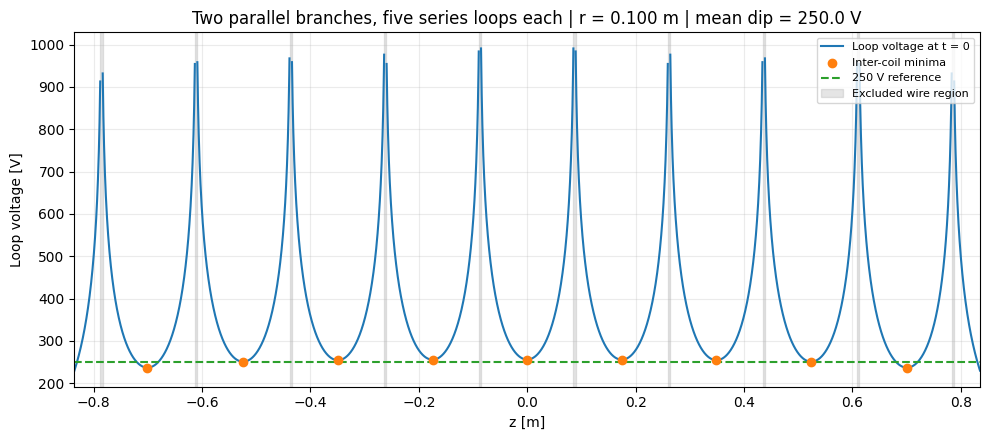

In [7]:
z_profile = np.linspace(min_z, max_z, z_res)
R_profile, Z_profile = np.meshgrid([measurement_radius], z_profile)
voltage_profile = (
    2 * np.pi * measurement_radius
    * system.total_Efield_phi(np.array([0.0]), R_profile, Z_profile)[0, :, 0]
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(z_profile, voltage_profile, label="Loop voltage at t = 0")
ax.scatter(valley_z, valley_voltage, color="tab:orange", zorder=3, label="Inter-coil minima")
ax.axhline(target_voltage, color="tab:green", linestyle="--", label=f"{target_voltage:g} V reference")
for i, z_pos in enumerate(z_positions):
    ax.axvspan(z_pos - wire_radius, z_pos + wire_radius, color="gray", alpha=0.2,
               label="Excluded wire region" if i == 0 else None)
ax.set_xlim(min_z, max_z)
ax.set_xlabel("z [m]")
ax.set_ylabel("Loop voltage [V]")
ax.set_title(f"Two parallel branches, five series loops each | r = {measurement_radius:.3f} m | mean dip = {mean_dip:.1f} V")
ax.grid(alpha=0.25)
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

## Current and voltage histories

These traces use the current functions assigned by the circuit class, rather than a second circuit implementation. The negative current follows the sign convention in your classes. Bank current counts each **parallel branch once**, not each series turn. Because all currents have the same sinusoidal time factor, the spatial valley positions remain fixed except when the entire voltage profile is zero.

Peak |coil current| range = 13.831 to 13.831 kA
Peak |bank current| = 27.661 kA


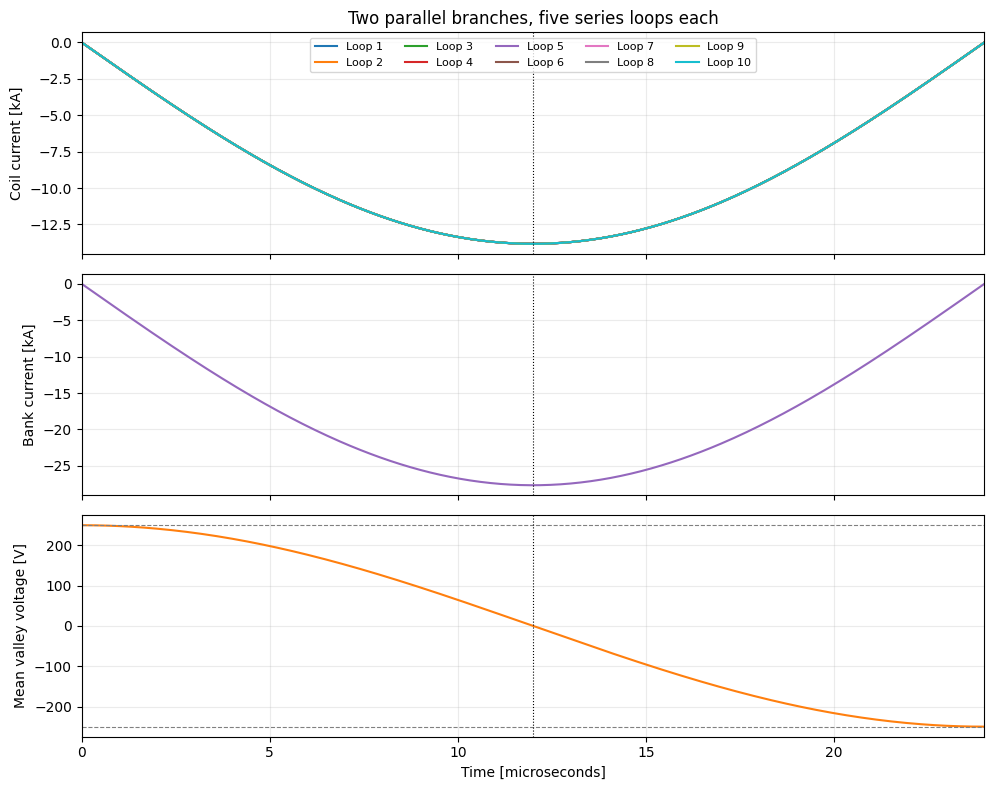

In [8]:
times = np.linspace(t_start, t_stop, frames)
I_loops = np.array([loop.current(times) for loop in loops])
I_bank = I_loops[0] + I_loops[num_left_branch]
R_valleys, Z_valleys = np.meshgrid([measurement_radius], valley_z)
voltage_at_valleys = (
    2 * np.pi * measurement_radius
    * system.total_Efield_phi(times, R_valleys, Z_valleys)[:, :, 0]
)
mean_signed_voltage = np.mean(voltage_at_valleys, axis=1)

print(f"Peak |coil current| range = {np.min(np.max(np.abs(I_loops), axis=1)) / 1e3:.3f} to {np.max(np.abs(I_loops)) / 1e3:.3f} kA")
print(f"Peak |bank current| = {np.max(np.abs(I_bank)) / 1e3:.3f} kA")

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i, waveform in enumerate(I_loops):
    axes[0].plot(times * 1e6, waveform / 1e3, label=f"Loop {i + 1}")
axes[0].set_ylabel("Coil current [kA]")
axes[0].legend(ncol=5, fontsize=8, loc="best")
axes[0].set_title("Two parallel branches, five series loops each")
axes[1].plot(times * 1e6, I_bank / 1e3, color="tab:purple")
axes[1].set_ylabel("Bank current [kA]")
axes[2].plot(times * 1e6, mean_signed_voltage, color="tab:orange")
axes[2].axhline(target_voltage, color="gray", linestyle="--", linewidth=0.8)
axes[2].axhline(-target_voltage, color="gray", linestyle="--", linewidth=0.8)
axes[2].set_ylabel("Mean valley voltage [V]")
axes[2].set_xlabel("Time [microseconds]")
for ax in axes:
    ax.axvline(t_peak * 1e6, color="black", linestyle=":", linewidth=0.8)
    ax.grid(alpha=0.25)
axes[-1].set_xlim(t_start * 1e6, t_stop * 1e6)
fig.tight_layout()
plt.show()

## Slow-motion loop-voltage animation

The full first current half-cycle (about 24 microseconds) is displayed in about 18 seconds. There are 361 temporal samples, about 67 ns apart. Playback is slowed down without altering the physics.

In [9]:
print(f"Physical frame spacing: {(t_stop - t_start) / (frames - 1) * 1e9:.2f} ns")
print(f"Playback duration: approximately {frames / fps:.2f} s")
display(HTML(voltage_anim.to_html5_video()))

Physical frame spacing: 66.67 ns
Playback duration: approximately 18.05 s


## Model limits

This is an ideal, resistance-free lumped LC circuit with vacuum, magnetoquasistatic fields, thin-wire self-inductance, and filament mutual inductance. It includes no plasma, aluminum plates, outer coils, background field, connecting-wire inductance, switch inductance, or losses. The voltage plotted is the induced EMF around one measurement circle, **not** the capacitor terminal voltage.

The predicted currents are large. In particular, the all-parallel bank has a very small ideal equivalent inductance, so omitted lead and switch inductances can materially change its pulse. These parameters demonstrate the requested field scale; they are not a validated capacitor-bank design.